# EmbedLab — Module 2: JEPA-inspired Self-Supervised Learning

**Status: trained and evaluated — negative result, written up honestly.** Same backbone as Module 1, different objective: mask a span of tokens and predict its *representation* from context (not its tokens, as BERT's MLM does; not contrasted against other examples, as Module 1's NT-Xent does) — no labels needed at all.

**Research question:** can a self-supervised objective produce a comparable embedding space without labeled pairs?

**Short answer: not with this simplified design — it collapsed.** The rest of this notebook shows the numbers and the likely mechanism, because the *why* here is more interesting than the headline result.

See the [project README](../README.md) for the full three-module arc.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from data.prepare import load_config, prepare_sts_b
from models.encoder import TextEncoder
from models.jepa_encoder import JEPAEncoder, sample_span_mask
from losses.span_prediction import SpanPredictionLoss

%matplotlib inline
pd.set_option("display.max_colwidth", 80)

config = load_config(ROOT / "configs" / "default.yaml")

## 1. Data: unlabeled STS-B sentences

`training/train_jepa.py` trains on the **same underlying sentences** as Module 1 (STS-B's train split, `sentence1` + `sentence2`, deduplicated) but deliberately ignores the similarity scores and binarized labels entirely — the point of this module is training *without* labeled pairs. Same data, different objective: a clean, apples-to-apples comparison of training signal, not data scale.

In [2]:
splits = prepare_sts_b(
    config["data"]["sts_b_dataset"],
    ROOT / config["data"]["cache_dir"],
    positive_threshold=config["data"]["positive_threshold"],
    negative_threshold=config["data"]["negative_threshold"],
)
unlabeled_sentences = sorted(set(splits["train"]["sentence1"]) | set(splits["train"]["sentence2"]))
print(f"{len(unlabeled_sentences)} unique unlabeled sentences (vs. Module 1's 2063 positive pairs)")

10536 unique unlabeled sentences (vs. Module 1's 2063 positive pairs)


## 2. Model: span masking + predictor + stop-gradient target

`models/jepa_encoder.py`'s `JEPAEncoder` wraps the same `TextEncoder` backbone with two branches that share weights:

- **Context branch:** a contiguous span of tokens is replaced with `[MASK]`, run through the backbone, mean-pooled over the masked positions, then passed through a small predictor head (2-layer MLP) — this is the *predicted* representation.
- **Target branch:** the original, unmasked sequence run through the *same* backbone with gradients stopped (`torch.no_grad()`), mean-pooled over the same span positions — this is the *target* representation.

The predictor + stop-gradient asymmetry is the standard BYOL/JEPA trick for avoiding the trivial "map everything to the same constant" solution — there's no separate EMA teacher network here (a simplification relative to real I-JEPA/data2vec), which turns out to matter, as section 5 shows.

In [3]:
jepa_demo = JEPAEncoder(model_name=config["model"]["backbone"], pooling=config["model"]["pooling"])

demo_sentences = [
    "A man is playing a guitar on the street.",
    "The stock market crashed yesterday after the announcement.",
]
batch = jepa_demo.encoder.tokenizer(demo_sentences, padding=True, truncation=True, max_length=32, return_tensors="pt")
span_mask = sample_span_mask(batch["attention_mask"], mask_span_ratio=config["jepa"]["mask_span_ratio"])

with torch.no_grad():
    predicted, target = jepa_demo(batch["input_ids"], batch["attention_mask"], span_mask)
print("masked tokens per sentence:", span_mask.sum(dim=1).tolist())
print("predicted shape:", predicted.shape, "target shape:", target.shape)
print("cosine sim(predicted, target) before training:", F.cosine_similarity(predicted, target).tolist())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


masked tokens per sentence: [2, 1]
predicted shape: torch.Size([2, 768]) target shape: torch.Size([2, 768])
cosine sim(predicted, target) before training: [0.011191220954060555, -0.02868916466832161]


## 3. Loss: cosine distance between predicted and target span representations

`losses/span_prediction.py` is `1 - cosine_similarity(predicted, target)`, averaged over the batch — same family as BYOL's loss. Note what's *absent* compared to Module 1's NT-Xent: no negatives, no other examples in the batch enter the loss at all. Each example is optimized independently toward its own target. That absence is the headline suspect for what goes wrong below.

## 4. Training: ran on Colab GPU

Same reasoning as Module 1: no local CUDA GPU, so the real run happened in `notebooks/colab_train_jepa.ipynb` on a free T4 — 3 epochs over 10536 sentences (≈329 steps/epoch, ≈987 steps total, batch size 32). The checkpoint was downloaded and evaluated locally below, the same way as Module 1's.

## 5. Results: STS-B Spearman ρ — a negative result

In [4]:
results = json.loads((ROOT / "results" / "sts_eval_test.json").read_text())
order = ["random", "frozen_bert", "jepa", "contrastive", "sbert"]
results_df = pd.DataFrame({"encoder": order, "spearman_rho": [results[k] for k in order]})
results_df

,encoder,spearman_rho
0,random,0.417962
1,frozen_bert,0.472912
2,jepa,0.299806
3,contrastive,0.767514
4,sbert,0.820325


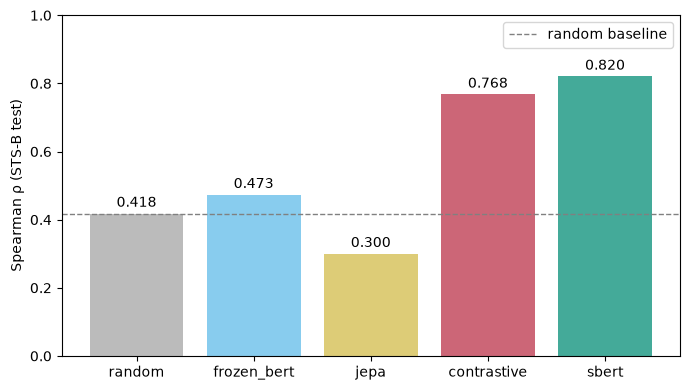

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#BBBBBB", "#88CCEE", "#DDCC77", "#CC6677", "#44AA99"]
ax.bar(results_df["encoder"], results_df["spearman_rho"], color=colors)
ax.set_ylabel("Spearman ρ (STS-B test)")
ax.set_ylim(0, 1)
ax.axhline(results["random"], color="gray", linestyle="--", linewidth=1, label="random baseline")
for i, v in enumerate(results_df["spearman_rho"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
ax.legend()
plt.tight_layout()
plt.show()

JEPA (0.300) scores *below the random encoder* (0.418) and frozen BERT (0.473) — fine-tuning made the embedding space actively worse for semantic similarity, not just unhelpful. Contrastive (0.768, Module 1) and SBERT (0.820) remain strong. This directly answers this module's research question: **no, not with this design** — and the next section shows why.

## 6. Diagnosis: representation collapse

A Spearman ρ below the random baseline is suspicious enough to investigate directly rather than just reporting the number. The first thing to check for any self-supervised predictive objective without explicit negatives: did the embedding space collapse to (near-)the same point for every input?

In [6]:
sample_sentences = splits["test"]["sentence1"].tolist()[:200]

collapse_rows = []
for name, checkpoint in [("frozen_bert", None), ("jepa", "jepa_encoder.pt"), ("contrastive", "contrastive_encoder.pt")]:
    enc = TextEncoder(model_name=config["model"]["backbone"], pooling=config["model"]["pooling"])
    if checkpoint:
        enc.load_state_dict(torch.load(ROOT / config["output"]["checkpoint_dir"] / checkpoint, map_location="cpu"))
    with torch.no_grad():
        emb = enc.encode(sample_sentences, max_length=64)
    norm_emb = F.normalize(emb, dim=-1)
    sims = norm_emb @ norm_emb.T
    off_diag = sims[~torch.eye(len(sims), dtype=torch.bool)]
    collapse_rows.append({
        "encoder": name,
        "mean_pairwise_cosine_sim": off_diag.mean().item(),
        "embedding_std": emb.std().item(),
    })

pd.DataFrame(collapse_rows)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,encoder,mean_pairwise_cosine_sim,embedding_std
0,frozen_bert,0.792793,0.373102
1,jepa,0.999678,0.419561
2,contrastive,0.270542,0.412399


**This confirms it.** 200 randomly sampled, mostly-unrelated STS-B test sentences have a mean pairwise cosine similarity of **~0.9997** under the JEPA encoder — essentially every sentence maps to nearly the same direction in embedding space, regardless of meaning. Frozen BERT (0.79) and the contrastive encoder (0.27) both retain far more directional spread. The embedding *magnitude* (std) didn't collapse — it's actually slightly higher than frozen BERT's — so this is specifically **directional/dimensional collapse**, not a trivial all-zeros solution.

**Likely mechanism:** the loss (`1 - cosine_similarity(predicted, target)`) has no term that pushes different examples' representations *apart* — Module 1's NT-Xent does this by construction (softmax over in-batch negatives in the denominator). The predictor + stop-gradient asymmetry (BYOL-style) is *necessary* to avoid the most trivial collapse (constant output regardless of input) but isn't always *sufficient* on its own — real BYOL/I-JEPA implementations also use a slowly-updated EMA teacher network, which this simplified version omits. Without that extra stabilization, nothing in the objective penalizes the whole batch converging toward a shared direction, and apparently it did.

## 7. UMAP — and why it doesn't show the collapse

`evaluation/visualize.py` produces the same paired-pair UMAP projection used in Module 1, now with a `jepa` panel added.

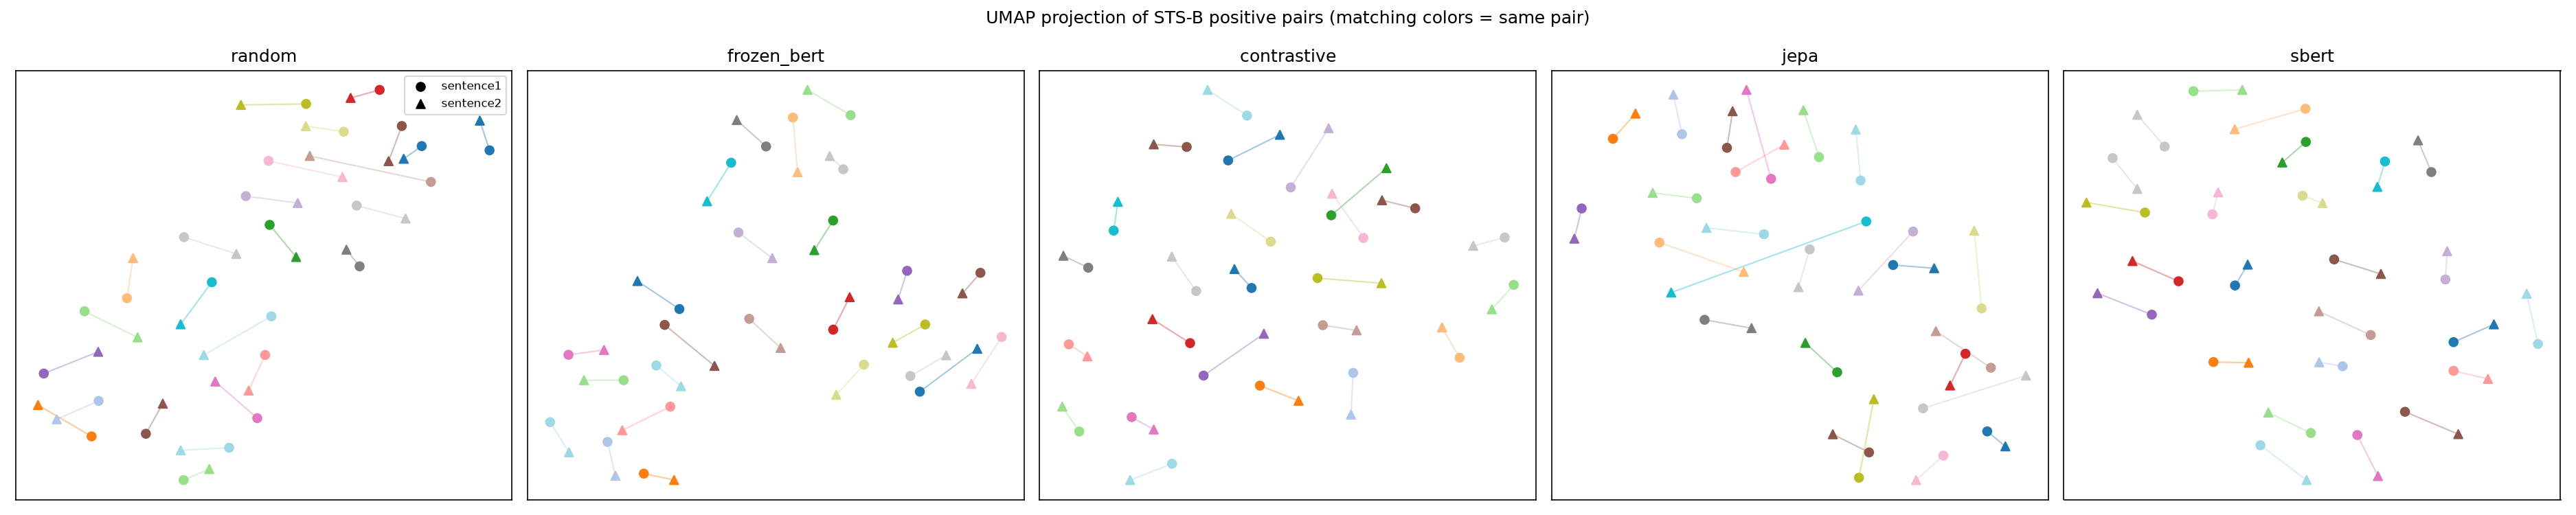

In [7]:
from IPython.display import Image
Image(filename=str(ROOT / "results" / "umap_test.png"))

Look closely: the `jepa` panel looks like a normal, well-spread scatter — **it does not visually reveal the collapse measured in section 6.** This is a real methodological trap, not a mistake in this specific plot: UMAP optimizes to preserve *local neighborhood structure* and rescales distances per-fit, so it will happily spread out points that are all at cosine similarity 0.9997 to each other, because it only cares about their *relative* ordering, not their absolute closeness. The lesson: UMAP plots are good for showing relative structure within one encoder, but **cannot be trusted to reveal global collapse** — always check a quantitative measure like pairwise cosine similarity directly, as in section 6, rather than eyeballing the projection.

## What's done / what's next

**Done — Module 2 is complete (negative result, written up):**
- `models/jepa_encoder.py` — span masking, predictor head, stop-gradient target branch
- `losses/span_prediction.py` — cosine-distance span representation loss
- `training/train_jepa.py` + `notebooks/colab_train_jepa.ipynb` — trained on 10536 unlabeled STS-B sentences on Colab GPU
- `evaluation/sts_eval.py` / `evaluation/visualize.py` — both extended to pick up `jepa_encoder.pt` automatically
- Diagnosed *why* it underperforms: representation collapse from missing explicit negatives / no EMA teacher, not a bug in the eval pipeline

**Next:**
- Module 3: swap the Module 1 (and, for contrast, Module 2) encoder into the RAG retrieval benchmark
- Possible follow-up (not planned yet): would adding an EMA teacher or a variance-regularization term (VICReg-style) fix the collapse? Left as an open question rather than re-running — the negative result as-is already answers this module's research question.